# CSE4261 Neural Network and Deep Learning  
## Assignment 7: CAM, Grad-CAM, and Integrated Gradients

This notebook solves all questions from the uploaded assignment. It includes the mathematical steps, final numerical answers, and Python code for reproducible computation/visualization.

## Common helper functions

In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.set_printoptions(precision=4, suppress=True)

def gap(feature_map):
    return np.mean(feature_map)

def normalize(M):
    M = np.asarray(M, dtype=float)
    mn, mx = M.min(), M.max()
    if mx == mn:
        return np.zeros_like(M)
    return (M - mn) / (mx - mn)

def cam(feature_maps, weights):
    M = np.zeros_like(feature_maps[0], dtype=float)
    for fk, wk in zip(feature_maps, weights):
        M += wk * fk
    return M

def show_heatmap(M, title="Heatmap"):
    plt.figure(figsize=(4, 3))
    plt.imshow(M)
    plt.colorbar()
    plt.title(title)
    for i in range(M.shape[0]):
        for j in range(M.shape[1]):
            plt.text(j, i, f"{M[i,j]:.2f}", ha="center", va="center")
    plt.xticks(range(M.shape[1]))
    plt.yticks(range(M.shape[0]))
    plt.show()

# 1. CAM calculation for the given CNN

Given:

\[
I=\begin{bmatrix}
1&2&3&2&1\\
0&1&2&1&0\\
1&3&4&3&1\\
0&1&2&1&0\\
1&2&3&2&1
\end{bmatrix}
\]

\[
f_1=\begin{bmatrix}1&2\\3&4\end{bmatrix},\quad
f_2=\begin{bmatrix}0&1\\1&0\end{bmatrix},\quad
f_3=\begin{bmatrix}2&1\\0&1\end{bmatrix}
\]

\[
w^c=[2,-1,1]
\]

In [2]:
I = np.array([
    [1, 2, 3, 2, 1],
    [0, 1, 2, 1, 0],
    [1, 3, 4, 3, 1],
    [0, 1, 2, 1, 0],
    [1, 2, 3, 2, 1]
], dtype=float)

f1 = np.array([[1, 2], [3, 4]], dtype=float)
f2 = np.array([[0, 1], [1, 0]], dtype=float)
f3 = np.array([[2, 1], [0, 1]], dtype=float)
weights = np.array([2, -1, 1], dtype=float)
feature_maps = [f1, f2, f3]

F = np.array([gap(f) for f in feature_maps])
score = np.dot(weights, F)
M = cam(feature_maps, weights)
M_norm = normalize(M)

print("GAP outputs [F1, F2, F3] =", F)
print("Class score Sc =", score)
print("CAM M =\n", M)
print("Normalized CAM M' =\n", M_norm)

GAP outputs [F1, F2, F3] = [2.5 0.5 1. ]
Class score Sc = 5.5
CAM M =
 [[4. 4.]
 [5. 9.]]
Normalized CAM M' =
 [[0.  0. ]
 [0.2 1. ]]


## 1(a) GAP outputs

\[
F_1=\frac{1+2+3+4}{4}=2.5
\]

\[
F_2=\frac{0+1+1+0}{4}=0.5
\]

\[
F_3=\frac{2+1+0+1}{4}=1.0
\]

So,

\[
F=[2.5,0.5,1.0]
\]

## 1(b) Class score

\[
S_c=\sum_k w_k^cF_k
\]

\[
S_c=2(2.5)+(-1)(0.5)+1(1.0)=5.5
\]

## 1(c) CAM

\[
M_c(x,y)=\sum_k w_k^c f_k(x,y)=2f_1-f_2+f_3
\]

\[
M_c=\begin{bmatrix}4&4\\5&9\end{bmatrix}
\]

## 1(d) Normalized CAM

\[
M'=\frac{M-\min(M)}{\max(M)-\min(M)}
\]

Here, \(\min(M)=4\), \(\max(M)=9\).

\[
M'=\begin{bmatrix}
0&0\\
0.2&1
\end{bmatrix}
\]

## 1(e) Mapping the 2×2 CAM back to the 5×5 image

The CAM is smaller because the last convolutional feature maps are \(2\times2\), while the input image is \(5\times5\). To map it back:

1. Upsample the \(2\times2\) CAM to \(5\times5\) using nearest-neighbor or bilinear interpolation.
2. Overlay the upsampled heatmap on the original \(5\times5\) image.
3. High CAM values show the image regions that contributed most to class \(c\).

The highest normalized value is \(1\) at the bottom-right feature-map location, so the corresponding lower-right region of the original image is most important for class \(c\).

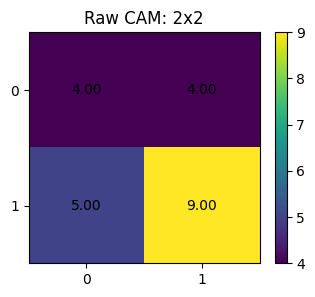

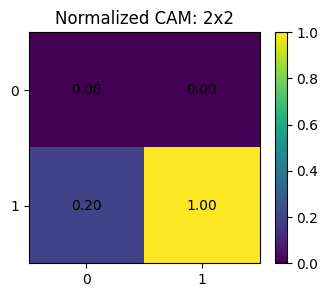

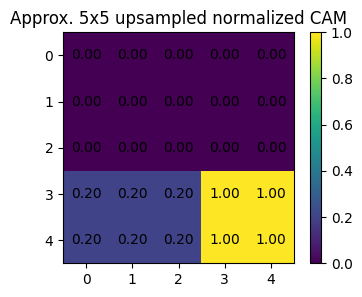

In [3]:
show_heatmap(M, "Raw CAM: 2x2")
show_heatmap(M_norm, "Normalized CAM: 2x2")

# Simple nearest-neighbor upsampling from 2x2 to 5x5
upsampled = np.kron(M_norm, np.ones((3, 3)))[:5, :5]
show_heatmap(upsampled, "Approx. 5x5 upsampled normalized CAM")

# 2. CAM steps for three own sets of \(\{I,f_1,f_2,f_3,w^c\}\)

In [4]:
cam_sets = [
    {
        "name": "Set 1",
        "I": np.array([[1,1,2,2,1],[0,1,2,1,0],[1,2,5,2,1],[0,1,2,1,0],[1,1,2,2,1]], float),
        "features": [np.array([[1,0],[2,3]], float), np.array([[2,1],[0,1]], float), np.array([[0,2],[1,1]], float)],
        "w": np.array([1, 2, -1], float)
    },
    {
        "name": "Set 2",
        "I": np.array([[2,0,1,0,2],[1,2,3,2,1],[0,1,4,1,0],[1,2,3,2,1],[2,0,1,0,2]], float),
        "features": [np.array([[2,1],[1,0]], float), np.array([[0,3],[1,2]], float), np.array([[1,1],[2,2]], float)],
        "w": np.array([2, -1, 3], float)
    },
    {
        "name": "Set 3",
        "I": np.array([[0,1,0,1,0],[1,2,3,2,1],[0,3,6,3,0],[1,2,3,2,1],[0,1,0,1,0]], float),
        "features": [np.array([[0,2],[4,2]], float), np.array([[1,0],[2,1]], float), np.array([[3,1],[0,2]], float)],
        "w": np.array([-1, 2, 1], float)
    }
]

for s in cam_sets:
    Fs = np.array([gap(f) for f in s["features"]])
    Sc = np.dot(s["w"], Fs)
    Mc = cam(s["features"], s["w"])
    Mn = normalize(Mc)
    print("\n", s["name"])
    print("GAP F =", Fs)
    print("Score Sc =", Sc)
    print("CAM =\n", Mc)
    print("Normalized CAM =\n", Mn)


 Set 1
GAP F = [1.5 1.  1. ]
Score Sc = 2.5
CAM =
 [[5. 0.]
 [1. 4.]]
Normalized CAM =
 [[1.  0. ]
 [0.2 0.8]]

 Set 2
GAP F = [1.  1.5 1.5]
Score Sc = 5.0
CAM =
 [[7. 2.]
 [7. 4.]]
Normalized CAM =
 [[1.  0. ]
 [1.  0.4]]

 Set 3
GAP F = [2.  1.  1.5]
Score Sc = 1.5
CAM =
 [[ 5. -1.]
 [ 0.  2.]]
Normalized CAM =
 [[1.     0.    ]
 [0.1667 0.5   ]]


For every set, the same CAM algorithm is used:

\[
F_k=\frac{1}{HW}\sum_x\sum_y f_k(x,y)
\]

\[
S_c=\sum_k w_k^cF_k
\]

\[
M_c(x,y)=\sum_k w_k^cf_k(x,y)
\]

\[
M'=\frac{M-\min(M)}{\max(M)-\min(M)}
\]

# 3. Grad-CAM for the above network and image

Grad-CAM uses gradients instead of directly using FC weights:

\[
\alpha_k^c=\frac{1}{Z}\sum_i\sum_j\frac{\partial S_c}{\partial A_{ij}^k}
\]

\[
L_{GradCAM}^c=ReLU\left(\sum_k \alpha_k^c A^k\right)
\]

For this simple GAP + FC network:

\[
S_c=\sum_k w_k^c\left(\frac{1}{4}\sum_{i,j}f_k(i,j)\right)
\]

Therefore:

\[
\frac{\partial S_c}{\partial f_k(i,j)}=\frac{w_k^c}{4}
\]

So:

\[
\alpha_k^c=\frac{w_k^c}{4}
\]

For \(w^c=[2,-1,1]\):

\[
\alpha^c=[0.5,-0.25,0.25]
\]

Grad-CAM alpha weights = [ 0.5  -0.25  0.25]
Raw Grad-CAM before ReLU =
 [[1.   1.  ]
 [1.25 2.25]]
Grad-CAM after ReLU =
 [[1.   1.  ]
 [1.25 2.25]]
Normalized Grad-CAM =
 [[0.  0. ]
 [0.2 1. ]]


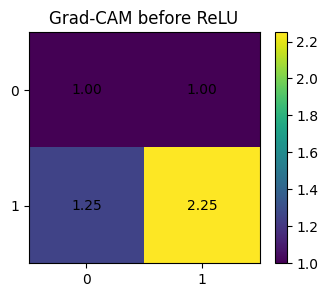

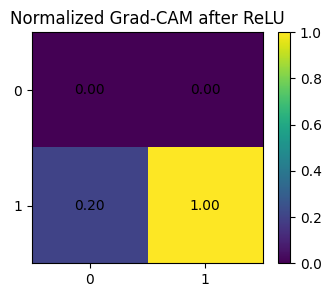

In [5]:
alpha = weights / 4.0
L_raw = cam(feature_maps, alpha)
L_gradcam = np.maximum(L_raw, 0)
L_gradcam_norm = normalize(L_gradcam)

print("Grad-CAM alpha weights =", alpha)
print("Raw Grad-CAM before ReLU =\n", L_raw)
print("Grad-CAM after ReLU =\n", L_gradcam)
print("Normalized Grad-CAM =\n", L_gradcam_norm)

show_heatmap(L_raw, "Grad-CAM before ReLU")
show_heatmap(L_gradcam_norm, "Normalized Grad-CAM after ReLU")

The Grad-CAM map is a scaled version of CAM here because the network has GAP followed directly by a linear FC layer. Scaling does not change the normalized heatmap.

# 4. Grad-CAM when multiple FC layers exist

When multiple FC layers exist, CAM cannot directly use final FC class weights because there is no single direct connection from each feature map to the class score. Grad-CAM still works because it uses backpropagated gradients.

Example architecture:

\[
A \rightarrow GAP \rightarrow FC_1 \rightarrow ReLU \rightarrow FC_2 \rightarrow S_c
\]

Steps:

1. Forward pass up to class score \(S_c\).
2. Backpropagate \(\partial S_c/\partial A_{ij}^k\).
3. Compute \(\alpha_k^c\) by global-average-pooling those gradients.
4. Compute \(ReLU(\sum_k\alpha_k^cA^k)\).

GAP F = [2.5 0.5 1. ]
z1 = [2.5  1.75]
h = ReLU(z1) = [2.5  1.75]
Class score = 3.25
dSc/dF = [ 1.5 -3.   1.5]
Grad-CAM alpha = [ 0.375 -0.75   0.375]
Grad-CAM =
 [[1.125 0.375]
 [0.375 1.875]]


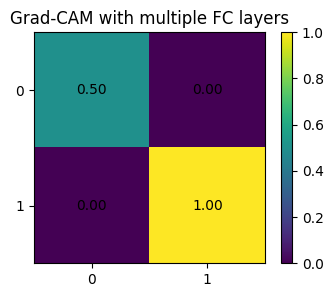

In [6]:
# Example with GAP -> FC1 -> ReLU -> FC2
F = np.array([gap(f) for f in feature_maps])
W1 = np.array([
    [1.0, -1.0, 0.5],
    [0.5,  1.0, -0.5]
])  # hidden_dim x 3
b1 = np.array([0.0, 0.5])
W2 = np.array([2.0, -1.0])  # class c output weights from hidden units

z1 = W1 @ F + b1
h = np.maximum(z1, 0)
Sc_multi = W2 @ h

# Backprop: dSc/dh = W2, dh/dz = 1 if z>0 else 0
active = (z1 > 0).astype(float)
dSc_dz1 = W2 * active
# dSc/dF = W1.T @ dSc_dz1
dSc_dF = W1.T @ dSc_dz1
# since F_k = mean(A_k), dSc/dA_kij = dSc/dF_k / 4
alpha_multi = dSc_dF / 4.0
L_multi = np.maximum(cam(feature_maps, alpha_multi), 0)

print("GAP F =", F)
print("z1 =", z1)
print("h = ReLU(z1) =", h)
print("Class score =", Sc_multi)
print("dSc/dF =", dSc_dF)
print("Grad-CAM alpha =", alpha_multi)
print("Grad-CAM =\n", L_multi)
show_heatmap(normalize(L_multi), "Grad-CAM with multiple FC layers")

# 5. Visualize before vs after ReLU as heatmaps

Before ReLU =
 [[-2.  1.]
 [ 3. -1.]]
After ReLU =
 [[0. 1.]
 [3. 0.]]


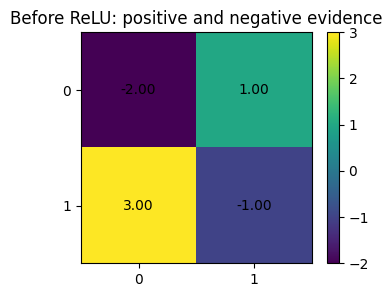

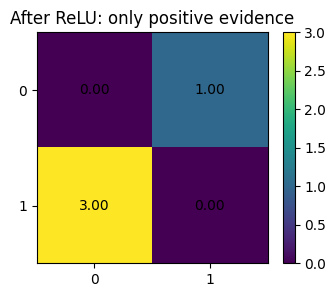

In [7]:
# Use an example that contains both negative and positive attribution
attr_before_relu = np.array([
    [-2.0,  1.0],
    [ 3.0, -1.0]
])
attr_after_relu = np.maximum(attr_before_relu, 0)

print("Before ReLU =\n", attr_before_relu)
print("After ReLU =\n", attr_after_relu)
show_heatmap(attr_before_relu, "Before ReLU: positive and negative evidence")
show_heatmap(attr_after_relu, "After ReLU: only positive evidence")

Before ReLU, negative values show regions that reduce the class score. After ReLU, only positive evidence for the target class remains.

# 6. What happens if we do not use ReLU?

Without ReLU, Grad-CAM becomes a full attribution map. It contains:

- positive evidence: regions that support the target class;
- negative evidence: regions that suppress the target class.

This can be useful for analysis, but the heatmap may be harder to interpret because positive and negative contributions are mixed.

Full attribution without ReLU =
 [[1.   1.  ]
 [1.25 2.25]]
Positive-only attribution with ReLU =
 [[1.   1.  ]
 [1.25 2.25]]


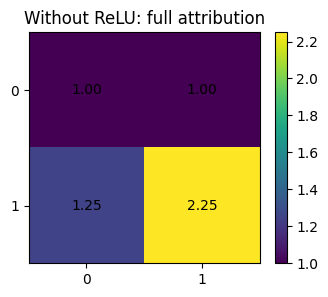

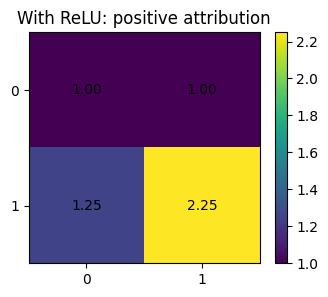

In [8]:
full_attribution = L_raw
positive_only = np.maximum(L_raw, 0)

print("Full attribution without ReLU =\n", full_attribution)
print("Positive-only attribution with ReLU =\n", positive_only)
show_heatmap(full_attribution, "Without ReLU: full attribution")
show_heatmap(positive_only, "With ReLU: positive attribution")

# 7. Integrated Gradients for \(F(x_1,x_2)=x_1^2+2x_2\)

Given:

\[
F(x_1,x_2)=x_1^2+2x_2
\]

Input:

\[
x=(2,3)
\]

Baseline:

\[
x'=(0,0)
\]

Number of steps:

\[
m=10
\]

Integrated Gradients discrete approximation:

\[
IG_i(x)\approx (x_i-x_i')\frac{1}{m}\sum_{k=1}^{m}\frac{\partial F(x'+\frac{k}{m}(x-x'))}{\partial x_i}
\]

Gradient:

\[
\nabla F(x_1,x_2)=(2x_1,2)
\]

Path point:

\[
x_k=x'+\frac{k}{m}(x-x')=(0.2k,0.3k)
\]

Gradient at path point:

\[
\nabla F(x_k)=(0.4k,2)
\]

For \(k=1,2,\dots,10\):

\[
\frac{1}{10}\sum_{k=1}^{10}0.4k=2.2
\]

\[
\frac{1}{10}\sum_{k=1}^{10}2=2
\]

So:

\[
IG_1=(2-0)(2.2)=4.4
\]

\[
IG_2=(3-0)(2)=6
\]

Final answer:

\[
IG(x)=(4.4,6.0)
\]

Completeness check:

\[
IG_1+IG_2=10.4
\]

\[
F(2,3)-F(0,0)=10
\]

The small difference occurs because this is a discrete right-Riemann approximation with only \(m=10\) steps. The exact IG is \((4,6)\).

In [9]:
def F_example(x):
    x1, x2 = x
    return x1**2 + 2*x2

def grad_F_example(x):
    x1, x2 = x
    return np.array([2*x1, 2.0])

def integrated_gradients(F, grad_F, x, baseline, m):
    x = np.array(x, dtype=float)
    baseline = np.array(baseline, dtype=float)
    total_grad = np.zeros_like(x)
    rows = []
    for k in range(1, m + 1):
        alpha = k / m
        xk = baseline + alpha * (x - baseline)
        gk = grad_F(xk)
        total_grad += gk
        rows.append((k, alpha, xk.copy(), gk.copy()))
    avg_grad = total_grad / m
    ig = (x - baseline) * avg_grad
    return ig, avg_grad, rows

ig, avg_grad, rows = integrated_gradients(F_example, grad_F_example, [2, 3], [0, 0], 10)

for k, alpha, xk, gk in rows:
    print(f"k={k:2d}, alpha={alpha:.1f}, x_k={xk}, grad={gk}")
print("Average gradient =", avg_grad)
print("IG =", ig)
print("Sum IG =", ig.sum())
print("F(x)-F(baseline) =", F_example(np.array([2,3])) - F_example(np.array([0,0])))

k= 1, alpha=0.1, x_k=[0.2 0.3], grad=[0.4 2. ]
k= 2, alpha=0.2, x_k=[0.4 0.6], grad=[0.8 2. ]
k= 3, alpha=0.3, x_k=[0.6 0.9], grad=[1.2 2. ]
k= 4, alpha=0.4, x_k=[0.8 1.2], grad=[1.6 2. ]
k= 5, alpha=0.5, x_k=[1.  1.5], grad=[2. 2.]
k= 6, alpha=0.6, x_k=[1.2 1.8], grad=[2.4 2. ]
k= 7, alpha=0.7, x_k=[1.4 2.1], grad=[2.8 2. ]
k= 8, alpha=0.8, x_k=[1.6 2.4], grad=[3.2 2. ]
k= 9, alpha=0.9, x_k=[1.8 2.7], grad=[3.6 2. ]
k=10, alpha=1.0, x_k=[2. 3.], grad=[4. 2.]
Average gradient = [2.2 2. ]
IG = [4.4 6. ]
Sum IG = 10.4
F(x)-F(baseline) = 10


# 8. Integrated Gradients for three own sets \(\{F,x,x',m\}\)

In [10]:
# Set A: F(x1,x2)=3x1+x2^2
def FA(x):
    x1, x2 = x
    return 3*x1 + x2**2

def grad_FA(x):
    x1, x2 = x
    return np.array([3.0, 2*x2])

# Set B: F(x1,x2)=x1*x2+x2
def FB(x):
    x1, x2 = x
    return x1*x2 + x2

def grad_FB(x):
    x1, x2 = x
    return np.array([x2, x1 + 1])

# Set C: F(x1,x2)=x1^2+x1*x2+2x2
def FC(x):
    x1, x2 = x
    return x1**2 + x1*x2 + 2*x2

def grad_FC(x):
    x1, x2 = x
    return np.array([2*x1 + x2, x1 + 2])

ig_sets = [
    ("Set A", FA, grad_FA, np.array([2, 4]), np.array([0, 0]), 10),
    ("Set B", FB, grad_FB, np.array([3, 2]), np.array([0, 0]), 10),
    ("Set C", FC, grad_FC, np.array([2, 3]), np.array([1, 1]), 20),
]

for name, Ffun, Gfun, x, b, m in ig_sets:
    ig, avg_grad, rows = integrated_gradients(Ffun, Gfun, x, b, m)
    print("\n" + name)
    print("x =", x, "baseline =", b, "m =", m)
    print("Average gradient =", avg_grad)
    print("IG =", ig)
    print("Sum IG =", ig.sum())
    print("F(x)-F(baseline) =", Ffun(x) - Ffun(b))


Set A
x = [2 4] baseline = [0 0] m = 10
Average gradient = [3.  4.4]
IG = [ 6.  17.6]
Sum IG = 23.6
F(x)-F(baseline) = 22

Set B
x = [3 2] baseline = [0 0] m = 10
Average gradient = [1.1  2.65]
IG = [3.3 5.3]
Sum IG = 8.6
F(x)-F(baseline) = 8

Set C
x = [2 3] baseline = [1 1] m = 20
Average gradient = [5.1   3.525]
IG = [5.1  7.05]
Sum IG = 12.149999999999999
F(x)-F(baseline) = 12


The same real implementation steps are followed for each set:

1. Choose baseline \(x'\).
2. Generate scaled inputs \(x_k=x'+\frac{k}{m}(x-x')\).
3. Compute gradients at each scaled input.
4. Average the gradients.
5. Multiply by \((x-x')\).

With larger \(m\), the IG sum gets closer to \(F(x)-F(x')\).

# 9. Compare Grad-CAM vs Integrated Gradients using the same situation

Use the original CNN feature maps and class score situation.

## Grad-CAM

- Works mainly on convolutional feature maps.
- Produces a coarse spatial heatmap.
- For the given network, the output is \(2\times2\), then upsampled to \(5\times5\).
- Highlights important image regions.
- Uses gradients with respect to feature maps.

## Integrated Gradients

- Works directly on input features or pixels.
- Produces attribution for every input dimension/pixel.
- Requires a baseline input.
- Uses gradients along a path from baseline to input.
- Satisfies the completeness idea: attribution sum approximates \(F(x)-F(x')\).

## Same-situation comparison

For the same image-classification problem:

- Grad-CAM says: “Which spatial region in the last feature map supports the class?”
- IG says: “How much did each input pixel contribute compared with a baseline image?”

Grad-CAM is usually easier to visualize for CNN image localization. IG is more detailed and pixel-level, but it depends strongly on the selected baseline.

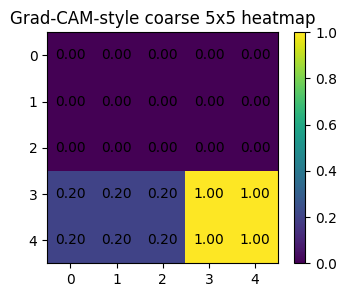

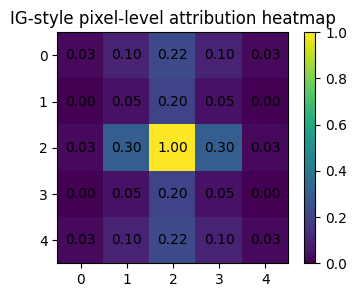

Grad-CAM output shape: (5, 5)
IG pixel attribution shape: (5, 5)


In [11]:
# Simple toy IG at image-pixel level for comparison.
# Suppose a toy linear image classifier score is F(I)=sum(W*I), baseline is zero image.
# For a linear model, IG = I * W exactly.
W_img = np.array([
    [0.1, 0.2, 0.3, 0.2, 0.1],
    [0.0, 0.2, 0.4, 0.2, 0.0],
    [0.1, 0.4, 1.0, 0.4, 0.1],
    [0.0, 0.2, 0.4, 0.2, 0.0],
    [0.1, 0.2, 0.3, 0.2, 0.1],
])
IG_img = I * W_img

show_heatmap(upsampled, "Grad-CAM-style coarse 5x5 heatmap")
show_heatmap(normalize(IG_img), "IG-style pixel-level attribution heatmap")
print("Grad-CAM output shape:", upsampled.shape)
print("IG pixel attribution shape:", IG_img.shape)